# Stage 5: Basic Fraud Modelling
This notebook fulfills the final practical deliverable for our study path. We will handle missing values, combat class imbalance, perform a time-based train/test split, and evaluate our models using a confusion matrix.

## 1. Load Data and Impute Missing Values

In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Load the dataset
df = pd.read_csv('training_dataset.csv')
print("Original Dataset Shape:", df.shape)
display(df.head())

# Impute missing values in 'transaction_amount' using the median
imputer = SimpleImputer(strategy='median')
df['transaction_amount'] = imputer.fit_transform(df[['transaction_amount']])
print("\nMissing values after imputation:\n", df.isnull().sum())


Original Dataset Shape: (9, 6)


,transaction_id,transaction_amount,customer_risk_score,days_since_signup,previous_transaction_count,is_fraud
0,1,250.50,0.10,259,0,0
1,3,1200.00,0.10,260,1,1
2,2,15.00,0.20,224,0,0
3,4,75.25,0.05,212,0,0
4,5,500.75,0.80,177,0,0



Missing values after imputation:
 transaction_id                0
transaction_amount            0
customer_risk_score           0
days_since_signup             0
previous_transaction_count    0
is_fraud                      0
dtype: int64


## 2. Feature Selection & Time-Based Split
To prevent data leakage, we cannot shuffle the data before splitting. We must simulate the real world where we train on the past and predict on the future.

In [2]:
# Drop transaction_id as it has no predictive power
X = df.drop(columns=['transaction_id', 'is_fraud'])
y = df['is_fraud']

# Perform a strictly sequential split (no shuffling)
# First 70% as training, last 30% as test
split_index = int(len(df) * 0.7)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])


Training set size: 6
Testing set size: 3


## 3. Train Baseline Logistic Regression Model
We use `class_weight='balanced'` because fraud is rare, so the model needs to penalize missing a fraudster much more heavily than a normal prediction.

--- Logistic Regression Evaluation ---
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.00      0.00      0.00         0

    accuracy                           0.67         3
   macro avg       0.50      0.33      0.40         3
weighted avg       1.00      0.67      0.80         3



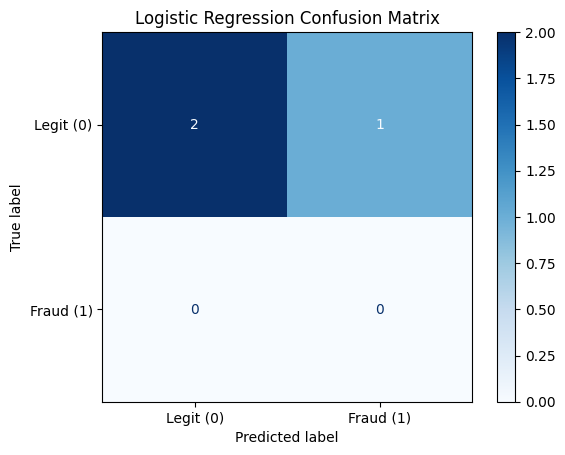

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

# Predict on the test set
y_pred_log = log_reg.predict(X_test)

# Output evaluation metrics
print("--- Logistic Regression Evaluation ---")
print(classification_report(y_test, y_pred_log, zero_division=0))

# Plot Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Legit (0)', 'Fraud (1)'])
disp_log.plot(cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()


## 4. Train Tree Model (Random Forest)
Tree models often capture non-linear relationships better than linear models.

--- Random Forest Evaluation ---
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.00      0.00      0.00         0

    accuracy                           0.33         3
   macro avg       0.50      0.17      0.25         3
weighted avg       1.00      0.33      0.50         3



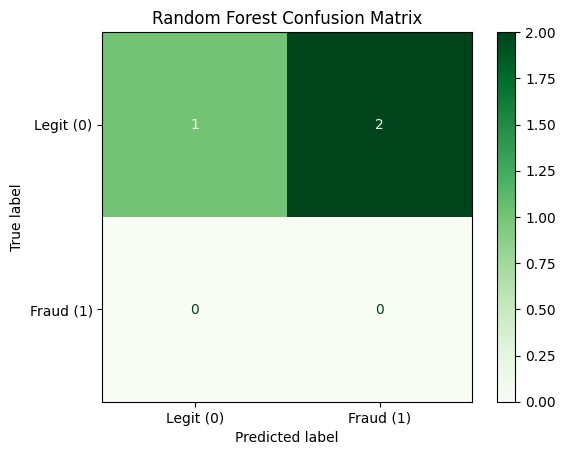

In [4]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Output evaluation metrics
print("--- Random Forest Evaluation ---")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Plot Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Legit (0)', 'Fraud (1)'])
disp_rf.plot(cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()
